In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv(r"G:\Mi unidad\DIPLOMATURA DATA ANALYTICS\PROYECTO ANALISIS DE DATOS\PROYECTO FINAL\data_cancelaciones_hoteleras\data\01-hotel_bookings.csv")
df_clean = df.copy()  # SIEMPRE trabajar sobre copia

print(f"Shape original: {df.shape}")
df.head()

Shape original: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


In [28]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

## Resumen de Hallazgos del EDA (Sprint 1)

Problemas identificados a tratar en este sprint:

| Problema | Columnas afectadas | Acción |
|---|---|---|
| Valores nulos reales | `children`, `country`, `agent`, `company` | Imputar / descartar |
| Duplicados | 31,994 filas (26.8%) | Eliminar |
| Outliers en adr | adr < 0 (1 registro), adr > 500 (3 registros) | Eliminar/cap |
| Registros sin personas | adults=0 + children=0 + babies=0 | Eliminar |
| Registros sin noches | stays_week=0 + stays_weekend=0 | Eliminar |
| Data leakage | `reservation_status`, `reservation_status_date` | Eliminar |
| children=10 | Valor imposible | Corregir |

In [29]:
def resumen_calidad(df, label=""):
    nulos = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    print(f"=== {label} ===")
    print(f"Shape:       {df.shape}")
    print(f"Nulos:       {nulos}")
    print(f"Duplicados:  {duplicados}")
    print()

resumen_calidad(df_clean, "ANTES de limpiar")

=== ANTES de limpiar ===
Shape:       (119390, 32)
Nulos:       129425
Duplicados:  31994



## 1. Eliminar columnas con data leakage

`reservation_status` y `reservation_status_date` revelan directamente
si la reserva fue cancelada. Incluirlas sería trampa para el modelo.
También eliminamos `company` porque tiene 94% de nulos y aporta muy poca información.

In [30]:
columnas_a_eliminar = ['reservation_status', 'reservation_status_date', 'company']
df_clean = df_clean.drop(columns=columnas_a_eliminar)

print(f"Columnas eliminadas: {columnas_a_eliminar}")
print(f"Shape: {df_clean.shape}")

Columnas eliminadas: ['reservation_status', 'reservation_status_date', 'company']
Shape: (119390, 29)


## 2. Eliminar duplicados

El EDA detectó 31,994 filas duplicadas (26.8% del dataset).
Pueden deberse a errores en la exportación del sistema hotelero.
Se eliminan manteniendo la primera ocurrencia.

In [31]:
n_antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
n_despues = len(df_clean)

print(f"Filas eliminadas: {n_antes - n_despues}")
print(f"Shape: {df_clean.shape}")

Filas eliminadas: 32260
Shape: (87130, 29)


## 3. Eliminar registros inválidos

### 3.1 Reservas sin personas
Registros donde adults=0, children=0 y babies=0 son errores de datos.
Una reserva sin ningún huésped no tiene sentido de negocio.

### 3.2 Reservas sin noches
Registros con 0 noches en semana Y 0 noches en fin de semana son inconsistentes.

In [32]:
# Reservas sin personas
mask_sin_personas = (
    (df_clean['adults'] == 0) & 
    (df_clean['children'].fillna(0) == 0) & 
    (df_clean['babies'] == 0)
)
print(f"Reservas sin personas: {mask_sin_personas.sum()}")
df_clean = df_clean[~mask_sin_personas]

# Reservas sin noches
mask_sin_noches = (
    (df_clean['stays_in_week_nights'] == 0) & 
    (df_clean['stays_in_weekend_nights'] == 0)
)
print(f"Reservas sin noches: {mask_sin_noches.sum()}")
df_clean = df_clean[~mask_sin_noches]

print(f"Shape: {df_clean.shape}")

Reservas sin personas: 166
Reservas sin noches: 591
Shape: (86373, 29)


## 4. Tratamiento de valores nulos

### 4.1 `children` (0.003% nulos)
Decisión: imputar con 0.
Justificación: si no se registró, lo más probable es que no hubiera niños.
El valor 10 es imposible (error de ingreso) → se corrige a 0.

### 4.2 `country` (0.41% nulos)
Decisión: imputar con la moda ('PRT' — Portugal, el país más frecuente).
Justificación: el porcentaje es bajo y la moda es representativa.

### 4.3 `agent` (13.7% nulos)
Decisión: imputar con 0.
Justificación: NaN en agent indica reserva directa (sin agente). 0 será el código para "sin agente".

In [33]:
# children: nulos → 0, valor 10 (imposible) → 0
df_clean['children'] = df_clean['children'].fillna(0)
df_clean.loc[df_clean['children'] == 10, 'children'] = 0
df_clean['children'] = df_clean['children'].astype(int)
print("children - nulos restantes:", df_clean['children'].isnull().sum())

# country: nulos → moda
moda_country = df_clean['country'].mode()[0]
df_clean['country'] = df_clean['country'].fillna(moda_country)
print(f"country - imputado con: '{moda_country}', nulos restantes:", df_clean['country'].isnull().sum())

# agent: nulos → 0 (reserva directa)
df_clean['agent'] = df_clean['agent'].fillna(0).astype(int)
print("agent - nulos restantes:", df_clean['agent'].isnull().sum())

print(f"\nNulos totales restantes: {df_clean.isnull().sum().sum()}")

children - nulos restantes: 0
country - imputado con: 'PRT', nulos restantes: 0
agent - nulos restantes: 0

Nulos totales restantes: 0


## 5. Tratamiento de outliers en `adr`

- 1 registro con adr negativo (error de sistema)
- 3 registros con adr > 500 (valores extremos)
- Se aplica recorte: adr < 0 se elimina, adr > 500 se capea al percentil 99

In [35]:
# Eliminar adr negativo
print(f"Registros con adr < 0: {(df_clean['adr'] < 0).sum()}")
df_clean = df_clean[df_clean['adr'] >= 0]

# Capear al percentil 99
p99 = df_clean['adr'].quantile(0.99)
print(f"Percentil 99 de adr: {p99:.2f}")
df_clean['adr'] = df_clean['adr'].clip(upper=p99)

print(f"adr máximo después de capping: {df_clean['adr'].max():.2f}")
print(f"Shape: {df_clean.shape}")

Registros con adr < 0: 0
Percentil 99 de adr: 262.00
adr máximo después de capping: 262.00
Shape: (86372, 29)


## 6. Corrección de tipos de datos

In [36]:
# Convertir arrival_date_month a número para el modelo
meses_orden = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_clean['arrival_date_month_num'] = df_clean['arrival_date_month'].map(meses_orden)

# Verificar tipos finales
print("Tipos de datos finales:")
print(df_clean.dtypes)

Tipos de datos finales:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent     

## 7. Verificación final

=== DESPUÉS de limpiar ===
Shape:       (86372, 30)
Nulos:       0
Duplicados:  21



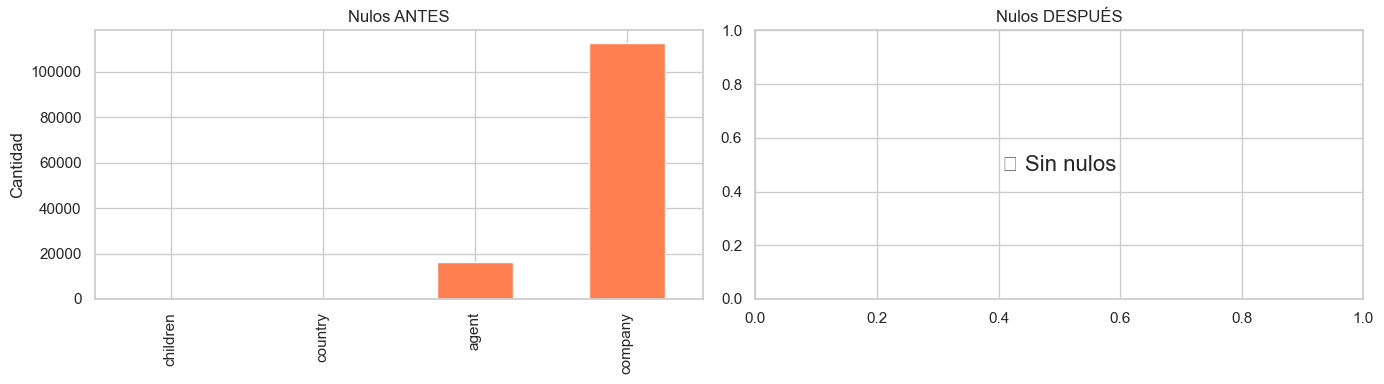


Resumen de cambios:
  Filas originales:  119,390
  Filas finales:     86,372
  Filas eliminadas:  33,018
  Columnas orig:     32
  Columnas finales:  30


In [37]:
resumen_calidad(df_clean, "DESPUÉS de limpiar")

# Comparativa visual de nulos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

nulos_antes = df.isnull().sum()
nulos_antes = nulos_antes[nulos_antes > 0]
nulos_antes.plot(kind='bar', ax=axes[0], color='coral', title='Nulos ANTES')
axes[0].set_ylabel('Cantidad')

nulos_despues = df_clean.isnull().sum()
nulos_despues = nulos_despues[nulos_despues > 0]
if len(nulos_despues) == 0:
    axes[1].text(0.5, 0.5, '✓ Sin nulos', ha='center', va='center', fontsize=16)
    axes[1].set_title('Nulos DESPUÉS')
else:
    nulos_despues.plot(kind='bar', ax=axes[1], color='steelblue', title='Nulos DESPUÉS')

plt.tight_layout()
plt.show()

print(f"\nResumen de cambios:")
print(f"  Filas originales:  {len(df):,}")
print(f"  Filas finales:     {len(df_clean):,}")
print(f"  Filas eliminadas:  {len(df) - len(df_clean):,}")
print(f"  Columnas orig:     {df.shape[1]}")
print(f"  Columnas finales:  {df_clean.shape[1]}")

## 8. Encoding

In [38]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [39]:
## 8. Encoding de variables categóricas
from sklearn.preprocessing import LabelEncoder

# OneHot para variables nominales de baja cardinalidad
df_clean = pd.get_dummies(df_clean, columns=['hotel', 'meal', 'market_segment', 
                                               'distribution_channel', 
                                               'deposit_type', 'customer_type',
                                               'reserved_room_type', 'assigned_room_type'],
                           drop_first=True)

# Ordinal para arrival_date_month (ya tiene orden numérico con arrival_date_month_num)
# No se necesita encoding adicional, ya lo hicimos en el bloque 6

print(f"Shape después de encoding: {df_clean.shape}")
print(f"Nuevas columnas: {df_clean.shape[1]}")

Shape después de encoding: (86372, 61)
Nuevas columnas: 61


In [40]:
df_clean.head(10)

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_month_num,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L
2,0,7,2015,July,27,1,0,1,1,0,0,GBR,0,0,0,0,0,0,75.0,0,0,7,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,0,13,2015,July,27,1,0,1,1,0,0,GBR,0,0,0,0,304,0,75.0,0,0,7,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0,14,2015,July,27,1,0,2,2,0,0,GBR,0,0,0,0,240,0,98.0,0,1,7,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,0,0,2015,July,27,1,0,2,2,0,0,PRT,0,0,0,0,0,0,107.0,0,0,7,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
7,0,9,2015,July,27,1,0,2,2,0,0,PRT,0,0,0,0,303,0,103.0,0,1,7,True,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
8,1,85,2015,July,27,1,0,3,2,0,0,PRT,0,0,0,0,240,0,82.0,0,1,7,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,1,75,2015,July,27,1,0,3,2,0,0,PRT,0,0,0,0,15,0,105.5,0,0,7,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
10,1,23,2015,July,27,1,0,4,2,0,0,PRT,0,0,0,0,240,0,123.0,0,0,7,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False
11,0,35,2015,July,27,1,0,4,2,0,0,PRT,0,0,0,0,240,0,145.0,0,0,7,True,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
12,0,68,2015,July,27,1,0,4,2,0,0,USA,0,0,0,0,240,0,97.0,0,3,7,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False

In [41]:
df_clean.head(10)

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_month_num,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L
2,0,7,2015,July,27,1,0,1,1,0,0,GBR,0,0,0,0,0,0,75.0,0,0,7,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,0,13,2015,July,27,1,0,1,1,0,0,GBR,0,0,0,0,304,0,75.0,0,0,7,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0,14,2015,July,27,1,0,2,2,0,0,GBR,0,0,0,0,240,0,98.0,0,1,7,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,0,0,2015,July,27,1,0,2,2,0,0,PRT,0,0,0,0,0,0,107.0,0,0,7,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
7,0,9,2015,July,27,1,0,2,2,0,0,PRT,0,0,0,0,303,0,103.0,0,1,7,True,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
8,1,85,2015,July,27,1,0,3,2,0,0,PRT,0,0,0,0,240,0,82.0,0,1,7,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,1,75,2015,July,27,1,0,3,2,0,0,PRT,0,0,0,0,15,0,105.5,0,0,7,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
10,1,23,2015,July,27,1,0,4,2,0,0,PRT,0,0,0,0,240,0,123.0,0,0,7,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False
11,0,35,2015,July,27,1,0,4,2,0,0,PRT,0,0,0,0,240,0,145.0,0,0,7,True,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
12,0,68,2015,July,27,1,0,4,2,0,0,USA,0,0,0,0,240,0,97.0,0,3,7,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False

In [42]:
import os
os.makedirs('../data/interim', exist_ok=True)

df_clean.to_csv('../data/interim/hotel_bookings_clean.csv', index=False)
print("✓ Dataset guardado en: data/interim/hotel_bookings_clean.csv")
print(f"Shape final: {df_clean.shape}")

✓ Dataset guardado en: data/interim/hotel_bookings_clean.csv
Shape final: (86372, 61)
